In [1]:
# ============================================================
# CHURN PREDICTION
# LOGISTIC REGRESSION
# Temporal validation + Core vs Extended model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [2]:
# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = "../data/churn_modeling_ready.csv"
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../data")

MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["observation_date"]
)

print("Shape:", df.shape)
print(
    "Date range:",
    df["observation_date"].min(),
    "to",
    df["observation_date"].max()
)

print("\nTarget:")
print(df["is_churn"].value_counts())

print("\nOverall churn rate:")
print(f"{df['is_churn'].mean():.2%}")

Shape: (32897, 32)
Date range: 2020-02-09 00:00:00 to 2020-05-10 00:00:00

Target:
is_churn
0    32252
1      645
Name: count, dtype: int64

Overall churn rate:
1.96%


In [4]:
# ============================================================
# 3. DEFINE FEATURE SETS
# ============================================================

# ------------------------------------------------------------
# MODEL A:
# Core customer + behavioral data
# ------------------------------------------------------------

core_categorical = [
    "channel",
    "country"
]

core_numeric = [
    "customer_age",
    "account_tenure_days",

    # Raw behavioral activity
    "post_per_month",
    "newfriend_per_month",
    "like_per_month",
    "adview_per_month",
    "dislike_per_month",
    "unfriend_per_month",
    "message_per_month",
    "reply_per_month",

    # Behavioral ratios
    "dislike_rate",
    "unfriend_rate",
    "reply_rate",
    "negative_activity_share",
    "adview_share"
]

core_features = (
    core_categorical
    + core_numeric
)



In [5]:
# ------------------------------------------------------------
# MODEL B:
# Core behavior + your subscription extension
# ------------------------------------------------------------

extended_categorical = [
    "channel",
    "country",
    "current_plan"
]

extended_numeric = core_numeric + [
    "current_mrr",
    "bill_period_months",
    "discount",
    "mrr_change",
    "upgrade_flag",
    "downsell_flag",
    "upgrade_last_90d",
    "downsell_last_90d"
]

extended_features = (
    extended_categorical
    + extended_numeric
)


print("Core model features:", len(core_features))
print("Extended model features:", len(extended_features))


Core model features: 17
Extended model features: 26


In [6]:
# ============================================================
# 4. TEMPORAL TRAIN / TEST SPLIT
# ============================================================

# Last month approximately becomes out-of-time test data.
# Training = observations before April 11
# Testing  = April 11 through May 10

SPLIT_DATE = pd.Timestamp("2020-04-11")

train_df = df[
    df["observation_date"] < SPLIT_DATE
].copy()

test_df = df[
    df["observation_date"] >= SPLIT_DATE
].copy()


print("\nTRAIN")
print("Rows:", len(train_df))
print(
    "Dates:",
    train_df["observation_date"].min(),
    "to",
    train_df["observation_date"].max()
)
print("Churns:", train_df["is_churn"].sum())
print("Churn rate:", f"{train_df['is_churn'].mean():.2%}")


print("\nTEST")
print("Rows:", len(test_df))
print(
    "Dates:",
    test_df["observation_date"].min(),
    "to",
    test_df["observation_date"].max()
)
print("Churns:", test_df["is_churn"].sum())
print("Churn rate:", f"{test_df['is_churn'].mean():.2%}")


# Target
y_train = train_df["is_churn"].astype(int)
y_test = test_df["is_churn"].astype(int)


TRAIN
Rows: 21252
Dates: 2020-02-09 00:00:00 to 2020-04-10 00:00:00
Churns: 457
Churn rate: 2.15%

TEST
Rows: 11645
Dates: 2020-04-11 00:00:00 to 2020-05-10 00:00:00
Churns: 188
Churn rate: 1.61%


In [7]:
# ============================================================
# 5. PIPELINE FACTORY
# ============================================================

def make_logistic_pipeline(categorical_features, numeric_features):

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                StandardScaler(),
                numeric_features
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_features
            )
        ]
    )

    model = LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        C=1.0
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    return pipeline



In [8]:
# ============================================================
# 6. MODEL A — CORE BEHAVIOR MODEL
# ============================================================

core_pipeline = make_logistic_pipeline(
    core_categorical,
    core_numeric
)

X_train_core = train_df[core_features]
X_test_core = test_df[core_features]

core_pipeline.fit(
    X_train_core,
    y_train
)

core_probability = core_pipeline.predict_proba(
    X_test_core
)[:, 1]

In [9]:
# ============================================================
# 7. MODEL B — EXTENDED SUBSCRIPTION MODEL
# ============================================================

extended_pipeline = make_logistic_pipeline(
    extended_categorical,
    extended_numeric
)

X_train_extended = train_df[extended_features]
X_test_extended = test_df[extended_features]

extended_pipeline.fit(
    X_train_extended,
    y_train
)

extended_probability = extended_pipeline.predict_proba(
    X_test_extended
)[:, 1]



In [10]:
# ============================================================
# 8. MODEL PERFORMANCE FUNCTION
# ============================================================

def evaluate_model(name, y_true, probabilities):

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    pr_auc = average_precision_score(
        y_true,
        probabilities
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print(
        f"Random PR baseline: "
        f"{y_true.mean():.4f}"
    )

    return {
        "model": name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }


core_results = evaluate_model(
    "Core Behavior Logistic Regression",
    y_test,
    core_probability
)

extended_results = evaluate_model(
    "Extended Subscription Logistic Regression",
    y_test,
    extended_probability
)




Core Behavior Logistic Regression
ROC-AUC: 0.6529
PR-AUC:  0.0426
Random PR baseline: 0.0161

Extended Subscription Logistic Regression
ROC-AUC: 0.6526
PR-AUC:  0.0438
Random PR baseline: 0.0161


In [11]:
# ============================================================
# 9. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame(
    [
        core_results,
        extended_results
    ]
)

print("\nMODEL COMPARISON")
display(comparison)



MODEL COMPARISON


,model,roc_auc,pr_auc
0,Core Behavior Logistic Regression,0.652920,0.042550
1,Extended Subscription Logistic Regression,0.652573,0.043781


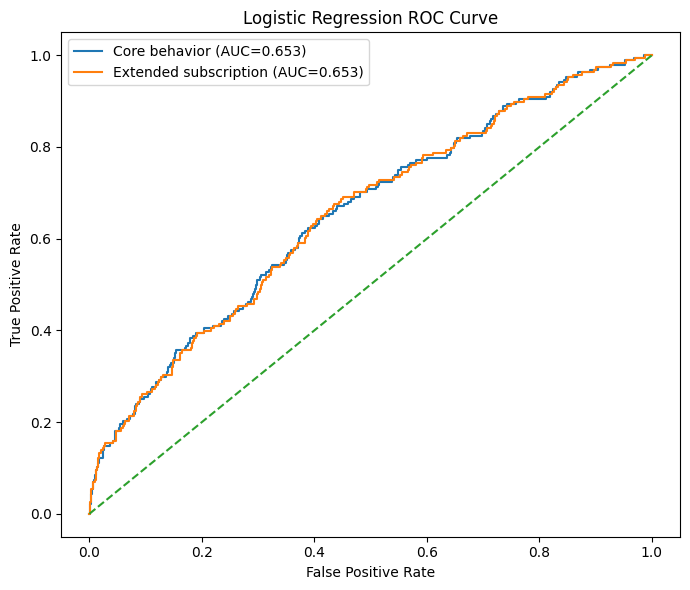

In [12]:
# ============================================================
# 10. ROC CURVES
# ============================================================

core_fpr, core_tpr, _ = roc_curve(
    y_test,
    core_probability
)

extended_fpr, extended_tpr, _ = roc_curve(
    y_test,
    extended_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    core_fpr,
    core_tpr,
    label=(
        "Core behavior "
        f"(AUC={core_results['roc_auc']:.3f})"
    )
)

plt.plot(
    extended_fpr,
    extended_tpr,
    label=(
        "Extended subscription "
        f"(AUC={extended_results['roc_auc']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

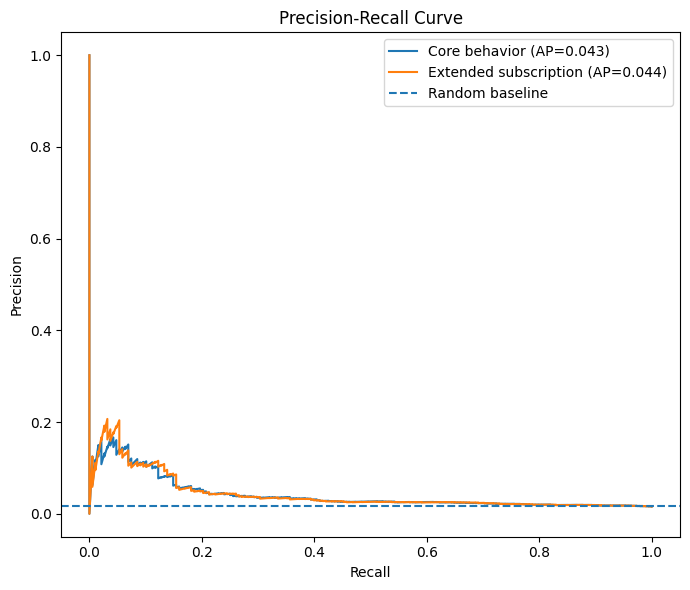

In [13]:
# ============================================================
# 11. PRECISION-RECALL CURVES
# ============================================================

core_precision, core_recall, _ = precision_recall_curve(
    y_test,
    core_probability
)

ext_precision, ext_recall, _ = precision_recall_curve(
    y_test,
    extended_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    core_recall,
    core_precision,
    label=(
        "Core behavior "
        f"(AP={core_results['pr_auc']:.3f})"
    )
)

plt.plot(
    ext_recall,
    ext_precision,
    label=(
        "Extended subscription "
        f"(AP={extended_results['pr_auc']:.3f})"
    )
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()



In [14]:
# ============================================================
# 12. LIFT / TOP-K BUSINESS PERFORMANCE
# ============================================================

def top_k_metrics(
    y_true,
    probabilities,
    percentages=(0.05, 0.10, 0.20)
):

    result = pd.DataFrame({
        "actual": np.asarray(y_true),
        "probability": probabilities
    })

    result = result.sort_values(
        "probability",
        ascending=False
    )

    overall_rate = result["actual"].mean()
    total_churns = result["actual"].sum()

    rows = []

    for pct in percentages:

        n = max(
            1,
            int(len(result) * pct)
        )

        top = result.head(n)

        top_churns = top["actual"].sum()
        top_rate = top["actual"].mean()

        lift = (
            top_rate / overall_rate
            if overall_rate > 0
            else np.nan
        )

        captured_churn = (
            top_churns / total_churns
            if total_churns > 0
            else np.nan
        )

        rows.append({
            "top_population_pct": pct * 100,
            "customers_targeted": n,
            "churners_found": int(top_churns),
            "precision": top_rate,
            "recall_of_all_churners": captured_churn,
            "lift": lift
        })

    return pd.DataFrame(rows)


print("\nCORE MODEL — TOP-K")
core_lift = top_k_metrics(
    y_test,
    core_probability
)

display(core_lift)


print("\nEXTENDED MODEL — TOP-K")
extended_lift = top_k_metrics(
    y_test,
    extended_probability
)

display(extended_lift)




CORE MODEL — TOP-K


,top_population_pct,customers_targeted,churners_found,precision,recall_of_all_churners,lift
0,5.0,582,34,0.058419,0.180851,3.618575
1,10.0,1164,48,0.041237,0.255319,2.554288
2,20.0,2329,74,0.031773,0.393617,1.968085



EXTENDED MODEL — TOP-K


,top_population_pct,customers_targeted,churners_found,precision,recall_of_all_churners,lift
0,5.0,582,33,0.056701,0.175532,3.512146
1,10.0,1164,49,0.042096,0.260638,2.607503
2,20.0,2329,74,0.031773,0.393617,1.968085


In [15]:
# ============================================================
# 13. CONFUSION MATRIX AT 0.50
# ============================================================

# This is shown for completeness.
# With ~2% churn, 0.50 usually is NOT the useful business threshold.

threshold = 0.50

extended_prediction_50 = (
    extended_probability >= threshold
).astype(int)

print("\nCONFUSION MATRIX — 0.50 THRESHOLD")

print(
    confusion_matrix(
        y_test,
        extended_prediction_50
    )
)

print("\nCLASSIFICATION REPORT — 0.50")

print(
    classification_report(
        y_test,
        extended_prediction_50,
        digits=4,
        zero_division=0
    )
)




CONFUSION MATRIX — 0.50 THRESHOLD
[[11457     0]
 [  188     0]]

CLASSIFICATION REPORT — 0.50
              precision    recall  f1-score   support

           0     0.9839    1.0000    0.9919     11457
           1     0.0000    0.0000    0.0000       188

    accuracy                         0.9839     11645
   macro avg     0.4919    0.5000    0.4959     11645
weighted avg     0.9680    0.9839    0.9758     11645



In [16]:
# ============================================================
# 14. BUSINESS THRESHOLD:
# TARGET TOP 10% HIGHEST-RISK CUSTOMERS
# ============================================================

risk_cutoff = np.quantile(
    extended_probability,
    0.90
)

top10_prediction = (
    extended_probability >= risk_cutoff
).astype(int)

print(
    "\nProbability cutoff for top 10%:",
    round(risk_cutoff, 4)
)

print("\nTOP 10% CONFUSION MATRIX")

print(
    confusion_matrix(
        y_test,
        top10_prediction
    )
)

print("\nTOP 10% CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        top10_prediction,
        digits=4,
        zero_division=0
    )
)




Probability cutoff for top 10%: 0.0433

TOP 10% CONFUSION MATRIX
[[10341  1116]
 [  139    49]]

TOP 10% CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9867    0.9026    0.9428     11457
           1     0.0421    0.2606    0.0724       188

    accuracy                         0.8922     11645
   macro avg     0.5144    0.5816    0.5076     11645
weighted avg     0.9715    0.8922    0.9287     11645



In [17]:
# ============================================================
# 15. COEFFICIENT INTERPRETATION
# ============================================================

preprocessor = (
    extended_pipeline
    .named_steps["preprocessor"]
)

feature_names = (
    preprocessor
    .get_feature_names_out()
)

coefficients = (
    extended_pipeline
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = (
    coef_df["coefficient"].abs()
)

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)


print("\nMOST INFLUENTIAL LOGISTIC FEATURES")
display(
    coef_df.head(25)
)


# Positive coefficient:
# higher predicted churn odds
print("\nSTRONGEST POSITIVE CHURN ASSOCIATIONS")

display(
    coef_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(15)
)


# Negative coefficient:
# lower predicted churn odds
print("\nSTRONGEST NEGATIVE CHURN ASSOCIATIONS")

display(
    coef_df
    .sort_values(
        "coefficient"
    )
    .head(15)
)




MOST INFLUENTIAL LOGISTIC FEATURES


,feature,coefficient,abs_coefficient
53,categorical__current_plan_basic,-0.989971,0.989971
24,categorical__channel_appstore2,-0.982646,0.982646
26,categorical__country_AR,-0.733171,0.733171
54,categorical__current_plan_plus,-0.701086,0.701086
23,categorical__channel_appstore1,-0.593212,0.593212
49,categorical__country_RU,-0.560162,0.560162
47,categorical__country_NZ,-0.515459,0.515459
8,numeric__message_per_month,-0.475708,0.475708
38,categorical__country_GR,-0.463832,0.463832
5,numeric__adview_per_month,-0.422690,0.422690



STRONGEST POSITIVE CHURN ASSOCIATIONS


,feature,coefficient,abs_coefficient
16,numeric__bill_period_months,0.399354,0.399354
9,numeric__reply_per_month,0.379569,0.379569
41,categorical__country_IT,0.366182,0.366182
14,numeric__adview_share,0.357559,0.357559
11,numeric__unfriend_rate,0.336025,0.336025
29,categorical__country_CA,0.328033,0.328033
13,numeric__negative_activity_share,0.325589,0.325589
51,categorical__country_US,0.324849,0.324849
45,categorical__country_NL,0.272302,0.272302
32,categorical__country_CO,0.237064,0.237064



STRONGEST NEGATIVE CHURN ASSOCIATIONS


,feature,coefficient,abs_coefficient
53,categorical__current_plan_basic,-0.989971,0.989971
24,categorical__channel_appstore2,-0.982646,0.982646
26,categorical__country_AR,-0.733171,0.733171
54,categorical__current_plan_plus,-0.701086,0.701086
23,categorical__channel_appstore1,-0.593212,0.593212
49,categorical__country_RU,-0.560162,0.560162
47,categorical__country_NZ,-0.515459,0.515459
8,numeric__message_per_month,-0.475708,0.475708
38,categorical__country_GR,-0.463832,0.463832
5,numeric__adview_per_month,-0.422690,0.422690


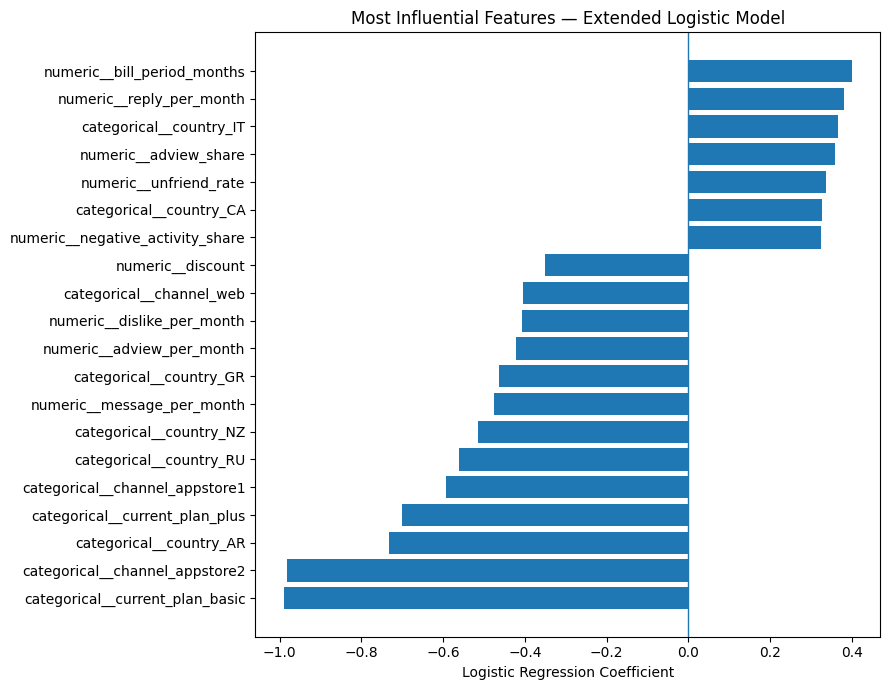

In [18]:
# ============================================================
# 16. COEFFICIENT PLOT
# ============================================================

top_coef = (
    coef_df
    .head(20)
    .sort_values("coefficient")
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_coef["feature"],
    top_coef["coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Logistic Regression Coefficient")
plt.title(
    "Most Influential Features — Extended Logistic Model"
)

plt.tight_layout()
plt.show()



In [19]:
# ============================================================
# 17. CREATE TEST PREDICTIONS
# ============================================================

predictions = test_df[
    [
        "account_id",
        "observation_date",
        "is_churn",
        "current_plan",
        "current_mrr",
        "upgrade_last_90d",
        "downsell_last_90d"
    ]
].copy()

predictions["churn_probability"] = (
    extended_probability
)

predictions["risk_rank"] = (
    predictions["churn_probability"]
    .rank(
        method="first",
        ascending=False
    )
)

predictions["risk_percentile"] = (
    predictions["churn_probability"]
    .rank(
        pct=True
    )
)



In [20]:
# ============================================================
# 18. REVENUE AT RISK
# ============================================================

predictions["monthly_revenue_at_risk"] = (
    predictions["churn_probability"]
    * predictions["current_mrr"]
)

predictions = predictions.sort_values(
    "churn_probability",
    ascending=False
)

display(
    predictions.head(20)
)

,account_id,observation_date,is_churn,current_plan,current_mrr,upgrade_last_90d,downsell_last_90d,churn_probability,risk_rank,risk_percentile,monthly_revenue_at_risk
4571,1635,2020-05-05,0,basic,10.00,0,0,0.438187,1.0,1.000000,4.381870
5500,1967,2020-04-13,0,plus,19.00,0,0,0.428452,2.0,0.999914,8.140589
27734,9874,2020-04-12,0,basic,9.50,0,0,0.408222,3.0,0.999828,3.878106
20357,7229,2020-05-08,0,premium,35.00,0,0,0.334208,4.0,0.999742,11.697263
5915,2112,2020-05-06,0,basic,10.00,0,0,0.308351,5.0,0.999657,3.083511
23698,8414,2020-04-16,0,basic,10.00,0,0,0.299627,6.0,0.999571,2.996271
12585,4462,2020-04-15,0,basic,9.50,0,0,0.284787,7.0,0.999485,2.705475
32320,12283,2020-04-30,1,basic,9.50,0,0,0.281347,8.0,0.999399,2.672801
11087,3931,2020-04-27,0,basic,10.00,0,0,0.266754,9.0,0.999313,2.667535
29937,10751,2020-05-08,0,basic,10.00,0,0,0.265291,10.0,0.999227,2.652909


In [21]:
# ============================================================
# 19. SAVE MODEL
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    / "logistic_regression_extended.pkl"
)

joblib.dump(
    extended_pipeline,
    MODEL_PATH
)

print(
    "\nSaved model:",
    MODEL_PATH
)


Saved model: ../models/logistic_regression_extended.pkl


In [22]:
# ============================================================
# 20. SAVE PREDICTIONS
# ============================================================

PREDICTION_PATH = (
    OUTPUT_DIR
    / "logistic_regression_test_predictions.csv"
)

predictions.to_csv(
    PREDICTION_PATH,
    index=False
)

print(
    "Saved predictions:",
    PREDICTION_PATH
)



Saved predictions: ../data/logistic_regression_test_predictions.csv


In [23]:
# ============================================================
# 21. SAVE MODEL COMPARISON
# ============================================================

comparison.to_csv(
    OUTPUT_DIR
    / "logistic_regression_model_comparison.csv",
    index=False
)



In [24]:
# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION COMPLETE")
print("=" * 60)

print(
    "\nCore model ROC-AUC:",
    round(core_results["roc_auc"], 4)
)

print(
    "Core model PR-AUC:",
    round(core_results["pr_auc"], 4)
)

print(
    "\nExtended model ROC-AUC:",
    round(extended_results["roc_auc"], 4)
)

print(
    "Extended model PR-AUC:",
    round(extended_results["pr_auc"], 4)
)

print(
    "\nTest churn baseline:",
    round(y_test.mean(), 4)
)


LOGISTIC REGRESSION COMPLETE

Core model ROC-AUC: 0.6529
Core model PR-AUC: 0.0426

Extended model ROC-AUC: 0.6526
Extended model PR-AUC: 0.0438

Test churn baseline: 0.0161
